<a href="https://colab.research.google.com/github/aesquivel94/operational-error-analyzer/blob/main/warehouse_operational_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operational Error Analyzer

This project simulates warehouse operational errors to analyze recurring issues, identify root causes, and estimate operational impact.

##Goal

The objective is to detect repeated failure patterns in warehouse workflows and evaluate how these issues affect time and efficiency.

In [85]:
# Import packages for data simulation, analysis, and visualization

import numpy as np      # numerical operations and random simulation
import pandas as pd     # data manipulation and tabular analysis
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns   # statistical data visualization
import os               # file and directory management

# Set default visualization theme for cleaner charts
sns.set_theme(style="whitegrid")

## 2. Simulate Warehouse Error Data

This section generates a synthetic dataset representing operational errors in warehouse workflows.

The simulation includes:
• process-specific error probabilities
• root cause categories
• identifier types (SKU, barcode, LPN)
• estimated operational impact in minutes

In [75]:
rng = np.random.default_rng(42)

n = 400

shifts = ["A", "B", "C"]
process_steps = ["receiving", "picking", "packing", "back_to_stock"]
identifier_types = ["sku", "barcode", "lpn"]

# Error probabilities by process step
step_error_weights = {
    "receiving": {
        "scan_failure": 0.35,
        "damage": 0.30,
        "lpn_error": 0.25,
        "missing_item": 0.10,
    },
    "picking": {
        "wrong_item": 0.35,
        "missing_item": 0.30,
        "lpn_error": 0.20,
        "scan_failure": 0.15,
    },
    "packing": {
        "wrong_item": 0.30,
        "damage": 0.25,
        "scan_failure": 0.25,
        "missing_item": 0.20,
    },
    "back_to_stock": {
        "missing_item": 0.35,
        "lpn_error": 0.30,
        "scan_failure": 0.20,
        "wrong_item": 0.15,
    },
}

# Possible root causes by error type
error_to_root = {
    "wrong_item": ["incorrect_location", "training_gap", "mislabel"],
    "missing_item": ["inventory_mismatch", "incorrect_location", "system_lag"],
    "scan_failure": ["damaged_label", "system_lag", "mislabel"],
    "lpn_error": ["mislabel", "system_lag", "training_gap"],
    "damage": ["training_gap", "incorrect_location", "damaged_label"],
}

# Most likely identifier type by error type
error_to_identifier = {
    "wrong_item": ["sku", "barcode"],
    "missing_item": ["sku", "lpn"],
    "scan_failure": ["barcode", "lpn"],
    "lpn_error": ["lpn"],
    "damage": ["barcode", "sku"],
}

def weighted_choice(options_dict):
    options = list(options_dict.keys())
    probs = list(options_dict.values())
    return rng.choice(options, p=probs)

start = np.datetime64("2025-01-01")
dates = start + rng.integers(0, 90, size=n).astype("timedelta64[D]")

rows = []

for _ in range(n):
    shift = rng.choice(shifts, p=[0.36, 0.34, 0.30])
    step = rng.choice(process_steps, p=[0.20, 0.35, 0.25, 0.20])

    error_type = weighted_choice(step_error_weights[step])
    root_cause = rng.choice(error_to_root[error_type])
    identifier_type = rng.choice(error_to_identifier[error_type])

    # impact minutes: most errors are small, some are larger
    base = rng.gamma(shape=2.0, scale=7.0)

    multiplier = {
        "missing_item": 1.4,
        "wrong_item": 1.3,
        "lpn_error": 1.2,
        "scan_failure": 1.0,
        "damage": 1.1,
    }[error_type]

    impact_minutes = int(round(base * multiplier))

    rows.append([
        str(dates[i]),
        shift,
        step,
        error_type,
        root_cause,
        identifier_type,
        impact_minutes
    ])

df = pd.DataFrame(rows, columns=[
    "date",
    "shift",
    "process_step",
    "error_type",
    "root_cause",
    "identifier_type",
    "impact_minutes"
])

df.head()

,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-28,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-01-28,A,packing,wrong_item,incorrect_location,sku,7
2,2025-01-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-01-28,C,picking,wrong_item,mislabel,sku,22
4,2025-01-28,A,back_to_stock,missing_item,incorrect_location,lpn,19


In [76]:
# Data Check

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             400 non-null    object
 1   shift            400 non-null    object
 2   process_step     400 non-null    object
 3   error_type       400 non-null    object
 4   root_cause       400 non-null    object
 5   identifier_type  400 non-null    object
 6   impact_minutes   400 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 22.0+ KB


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-28,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-01-28,A,packing,wrong_item,incorrect_location,sku,7
2,2025-01-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-01-28,C,picking,wrong_item,mislabel,sku,22
4,2025-01-28,A,back_to_stock,missing_item,incorrect_location,lpn,19


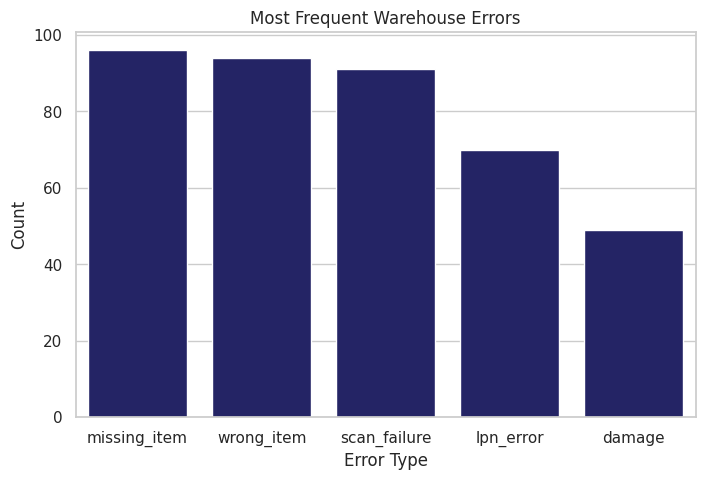

In [77]:
# First Analysis: Error Frequency



error_counts = df["error_type"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=error_counts.index, y=error_counts.values, color='midnightblue')
plt.title("Most Frequent Warehouse Errors")
plt.ylabel("Count")
plt.xlabel("Error Type")
# plt.xticks(rotation=90)
plt.show()

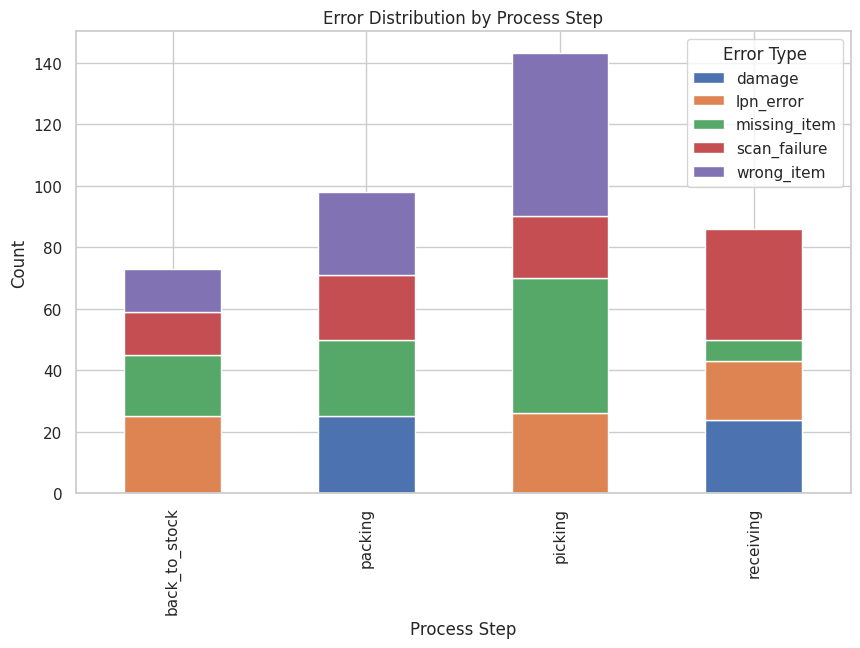

In [78]:
# Second Analysis: Errors by Process Step

step_errors = pd.crosstab(df["process_step"], df["error_type"])

step_errors.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Error Distribution by Process Step")
plt.ylabel("Count")
plt.xlabel("Process Step")
plt.legend(title="Error Type")
plt.show()

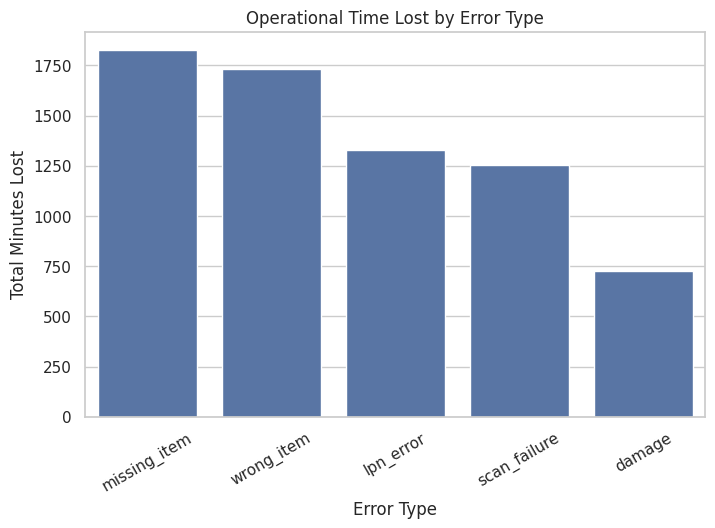

In [79]:
# Third Analysis: Operational Cost

cost_analysis = df.groupby("error_type")["impact_minutes"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cost_analysis.index, y=cost_analysis.values)
plt.title("Operational Time Lost by Error Type")
plt.ylabel("Total Minutes Lost")
plt.xlabel("Error Type")
plt.xticks(rotation=30)
plt.show()

In [80]:
# 8. Recurring error chain analysis

# Create a simple previous_error column to simulate error chains
possible_previous = {
    "wrong_item": ["lpn_error", "scan_failure", "missing_item"],
    "missing_item": ["wrong_item", "lpn_error", "scan_failure"],
    "scan_failure": ["scan_failure", "lpn_error"],
    "lpn_error": ["scan_failure", "missing_item"],
    "damage": ["scan_failure", "wrong_item"]
}

df["previous_error"] = df["error_type"].apply(
    lambda x: rng.choice(possible_previous[x])
)

df.head()


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes,previous_error
0,2025-01-28,C,back_to_stock,lpn_error,system_lag,lpn,18,scan_failure
1,2025-01-28,A,packing,wrong_item,incorrect_location,sku,7,scan_failure
2,2025-01-28,A,back_to_stock,scan_failure,system_lag,barcode,12,scan_failure
3,2025-01-28,C,picking,wrong_item,mislabel,sku,22,scan_failure
4,2025-01-28,A,back_to_stock,missing_item,incorrect_location,lpn,19,scan_failure


In [81]:
# Save Dataset
os.makedirs("../data", exist_ok=True)

df.to_csv("../data/bts_errors.csv", index=False)
print("Saved:", df.shape)

Saved: (400, 8)


In [82]:
chain_counts = (
    df.groupby(["previous_error", "error_type"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

chain_counts.head(10)

,previous_error,error_type,count
1,lpn_error,scan_failure,47
8,scan_failure,scan_failure,44
3,missing_item,lpn_error,40
7,scan_failure,missing_item,36
2,lpn_error,wrong_item,32
9,scan_failure,wrong_item,31
4,missing_item,wrong_item,31
0,lpn_error,missing_item,30
11,wrong_item,missing_item,30
6,scan_failure,lpn_error,30


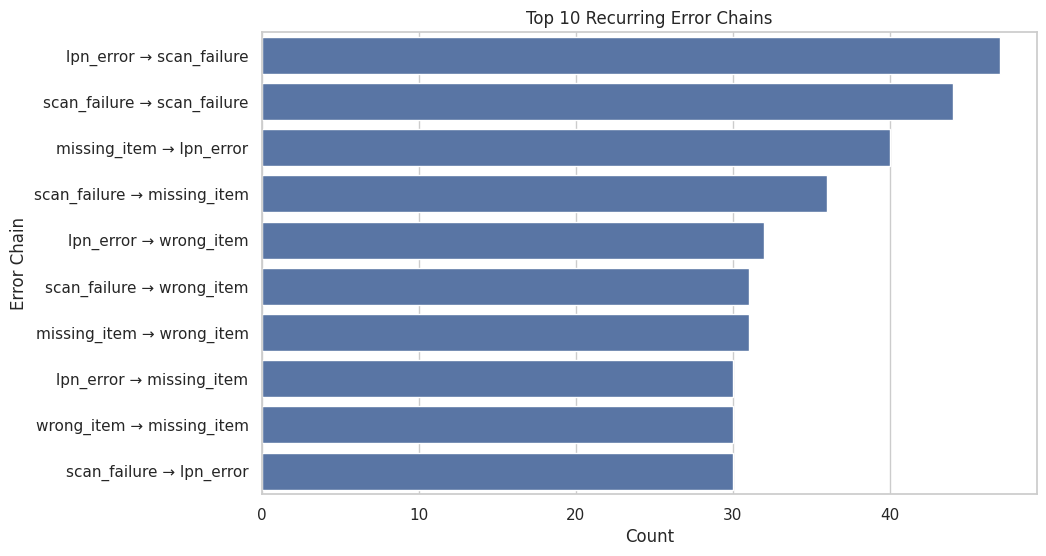

In [83]:
top_chains = chain_counts.head(10).copy()
top_chains["chain"] = top_chains["previous_error"] + " → " + top_chains["error_type"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_chains, x="count", y="chain")
plt.title("Top 10 Recurring Error Chains")
plt.xlabel("Count")
plt.ylabel("Error Chain")
plt.show()